In [11]:
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [5]:
GLOBAL_SEED = 42
IMAGE_SIZE = (200, 200)

DATASET_URL = "https://www.kaggle.com/api/v1/datasets/download/debashishsau/aslamerican-sign-language-aplhabet-dataset"

RAW_DATA_DIR = "../data/raw/"
ZIP_FILE_PATH = RAW_DATA_DIR + "asl-dataset.zip"
EXTRACT_DIRECTORY = RAW_DATA_DIR + "ASL_Alphabet_Dataset"

## Data Preparation

**Dataset Source**: [ASL Alphabet Dataset](https://www.kaggle.com/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset)

- **Size**: 223,000+ labeled images  
- **Classes**: 28 (A-Z letters + "space" + "nothing")
- **Resolution**: 200x200 RGB images

In [ ]:
from asl_classifier.data.download_data import download_data, extract_data

download_data(DATASET_URL, ZIP_FILE_PATH)
extract_data(ZIP_FILE_PATH, EXTRACT_DIRECTORY)

### Data Format

**Input**: 200x200 RGB images of ASL hand gestures  
**Output**: Multi-class labels (28 categories)

| Component | Type | Shape/Range | Description |
|-----------|------|-------------|-------------|
| Images | Tensor | (200, 200, 3) | Normalized RGB pixel values |
| Labels | Categorical | 0-27 | Integer-encoded class labels |

In [ ]:
from tensorflow.keras.utils import image_dataset_from_directory

# Load training and validation datasets
# Using 80/20 split for train/validation
train_ds, val_ds = image_dataset_from_directory(
    "../data/raw/ASL_Alphabet_Dataset/asl_alphabet_train",
    image_size=IMAGE_SIZE,
    batch_size=32,
    validation_split=0.2,
    subset="both",
    seed=GLOBAL_SEED
)

print(f"Training batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")

In [8]:
# Display class information
class_names = train_ds.class_names
print(f"Number of classes: {len(class_names)}")
print(f"Classes: {class_names}")

Number of classes: 28
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'nothing', 'space']


In [9]:
# Verify data format
for images, labels in train_ds.take(1):
    print(f"Batch shape: {images.shape}")
    print(f"Single image shape: {images[0].shape}")
    print(f"Label batch shape: {labels.shape}")
    print(f"Sample labels: {labels[:5].numpy()}")
    break

Batch shape: (32, 200, 200, 3)
Single image shape: (200, 200, 3)
Label batch shape: (32,)
Sample labels: [24 15  1  2  7]


## Exploratory Data Analysis

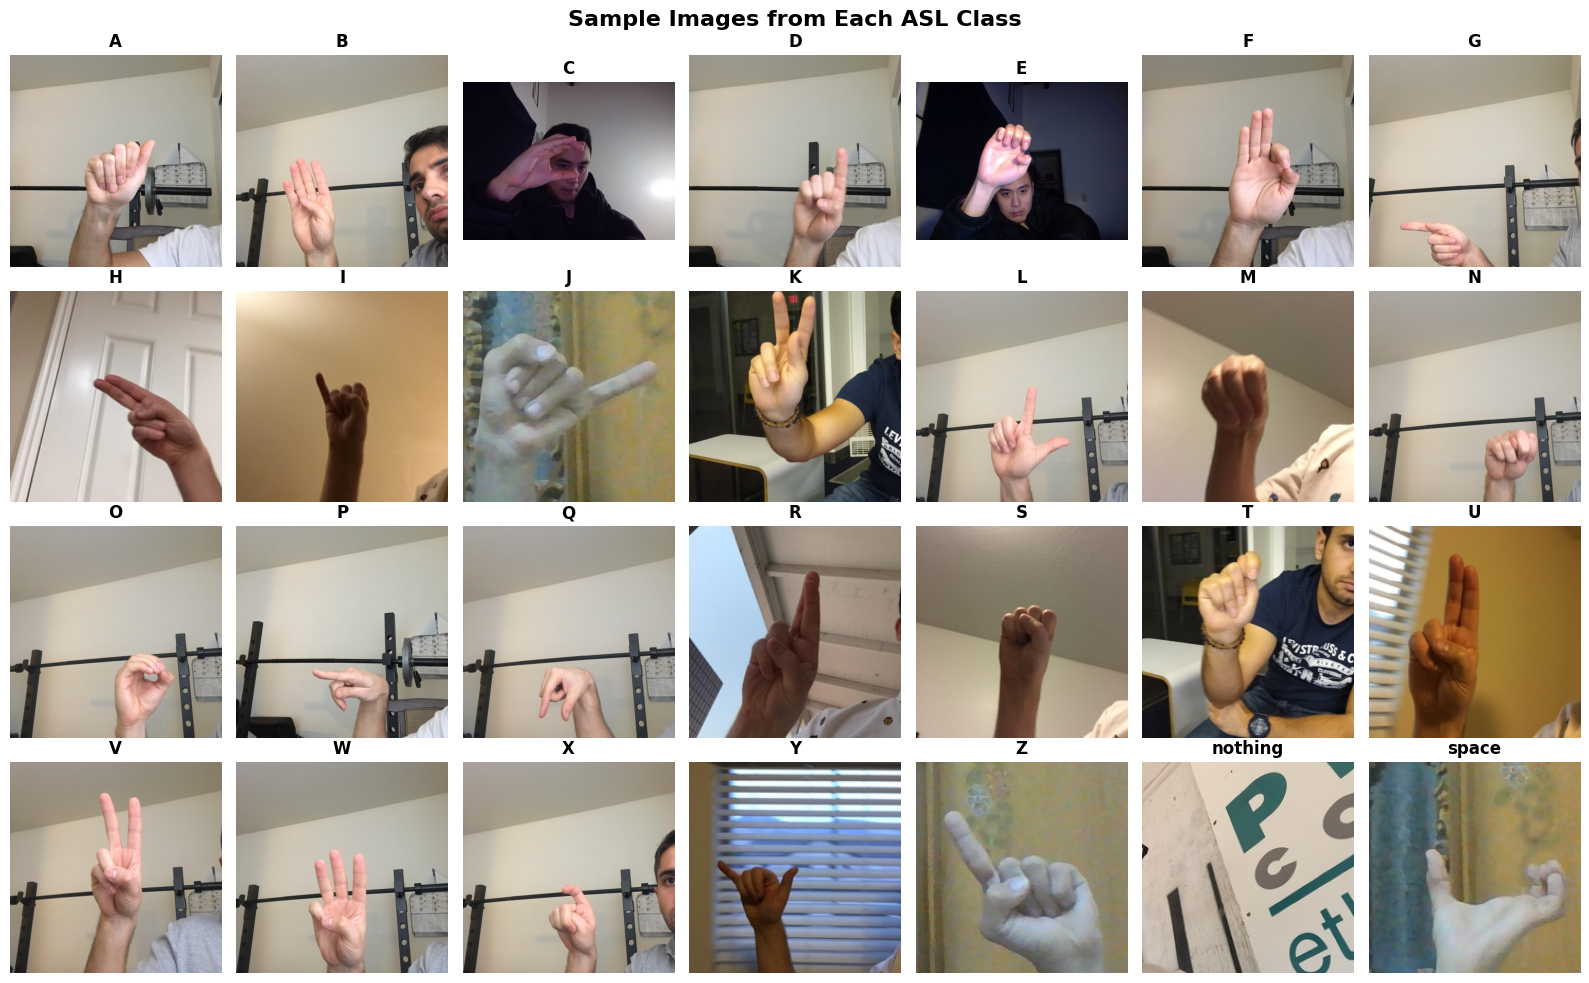

In [12]:
# Visualize sample images from each class
base_path = '../data/raw/ASL_Alphabet_Dataset/asl_alphabet_train'

plt.figure(figsize=(16, 10))
for i, class_name in enumerate(class_names):
    class_dir = os.path.join(base_path, class_name)
    if os.path.exists(class_dir):
        image_files = os.listdir(class_dir)
        if image_files:
            image_path = os.path.join(class_dir, image_files[0])
            img = Image.open(image_path)
            
            ax = plt.subplot(4, 7, i + 1)
            plt.imshow(img)
            plt.title(f"{class_name}", fontsize=12, fontweight='bold')
            plt.axis("off")

plt.suptitle("Sample Images from Each ASL Class", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

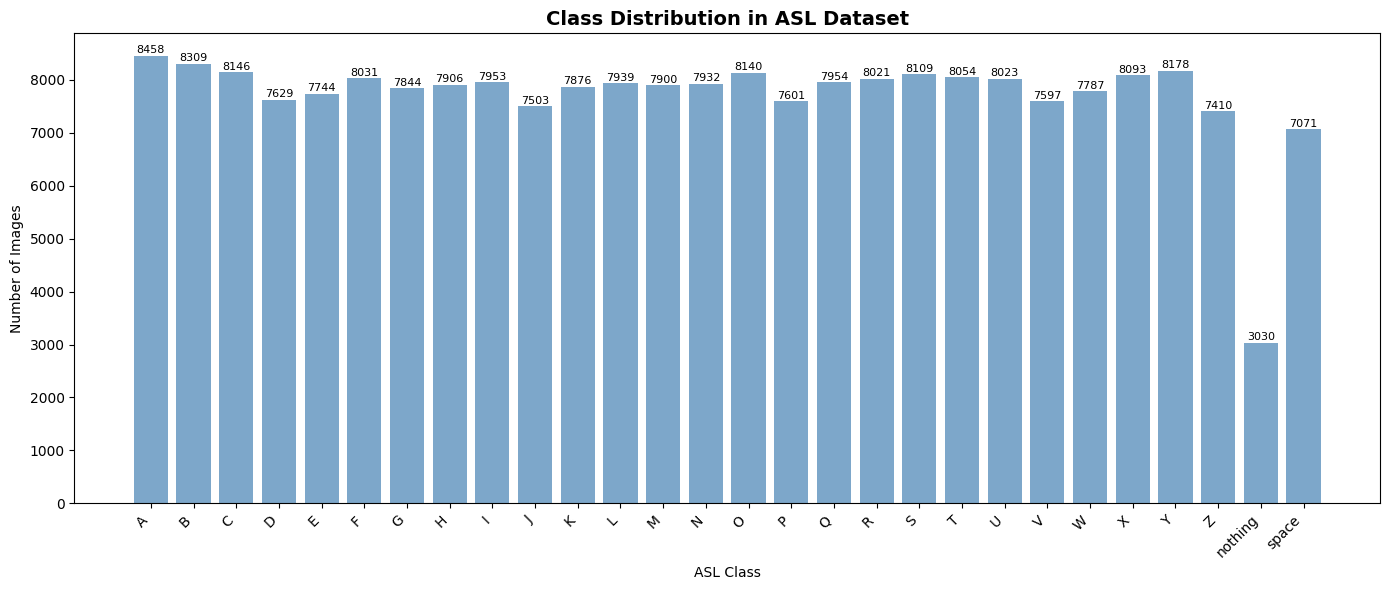

Total images: 216,238
Average images per class: 7723


In [13]:
# Analyze class distribution
class_counts = {}
for cls in class_names:
    class_dir = os.path.join(base_path, cls)
    if os.path.exists(class_dir):
        class_counts[cls] = len(os.listdir(class_dir))

plt.figure(figsize=(14, 6))
bars = plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution in ASL Dataset", fontsize=14, fontweight='bold')
plt.xlabel("ASL Class")
plt.ylabel("Number of Images")

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'{int(height)}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print(f"Total images: {sum(class_counts.values()):,}")
print(f"Average images per class: {sum(class_counts.values())/len(class_counts):.0f}")

### Data Quality Assessment

**Observations:**
- **Class Imbalance**: The "nothing" class has fewer samples than alphabet classes, which may affect model performance
- **Consistent Format**: All images are 200x200 RGB with uniform backgrounds
- **Data Quality**: High-quality images with clear gesture visibility

**Preprocessing Steps:**
1. **Normalization**: Pixel values scaled from [0, 255] to [0, 1] range
2. **Data Pipeline Optimization**: Shuffling and prefetching for efficient training
3. **Class Filtering**: Removed irrelevant "delete" gesture class

In [14]:
# Data preprocessing and optimization
normalization_layer = tf.keras.layers.Rescaling(1./255)
autotune = tf.data.AUTOTUNE

# Apply normalization and optimization
train_ds = train_ds.shuffle(1000) \
    .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=autotune) \
    .prefetch(buffer_size=autotune)

val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=autotune) \
    .prefetch(buffer_size=autotune)

print("✓ Data preprocessing complete")
print("✓ Normalization applied (pixel values: 0-1)")
print("✓ Training data shuffled and prefetched")

✓ Data preprocessing complete
✓ Normalization applied (pixel values: 0-1)
✓ Training data shuffled and prefetched
